In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import parse_slurm as ps
import data_analysis as da
import glob
import pandas as pd

In [3]:
metric = 'AveCPU'

# Docking Protein-Protein CPU Analysis 

In [4]:
dpp = pd.read_csv('./data/clean/data_dpp.csv')
dpp_cpu = dpp[['AveCPU', 'NCPUS']]

## Descriptive Analysis

In [5]:
for x in [4, 8, 16, 32]:
    group = ps.get_group(dpp_cpu, ncpus=x)
    print(group.describe())

          AveCPU  NCPUS
count  13.000000   13.0
mean    5.051504    4.0
std     0.449416    0.0
min     4.271908    4.0
25%     4.661453    4.0
50%     5.268843    4.0
75%     5.374713    4.0
max     5.664912    4.0
          AveCPU  NCPUS
count  16.000000   16.0
mean   10.077429    8.0
std     0.490726    0.0
min     8.875168    8.0
25%     9.925960    8.0
50%    10.152461    8.0
75%    10.269070    8.0
max    10.900644    8.0
          AveCPU  NCPUS
count  10.000000   10.0
mean   18.035335   16.0
std     1.652299    0.0
min    15.024704   16.0
25%    17.451633   16.0
50%    18.581917   16.0
75%    19.236872   16.0
max    19.598742   16.0
          AveCPU  NCPUS
count  13.000000   13.0
mean   30.615049   32.0
std     1.877973    0.0
min    27.508961   32.0
25%    29.860045   32.0
50%    30.298496   32.0
75%    32.277043   32.0
max    33.605222   32.0


## Boxplots

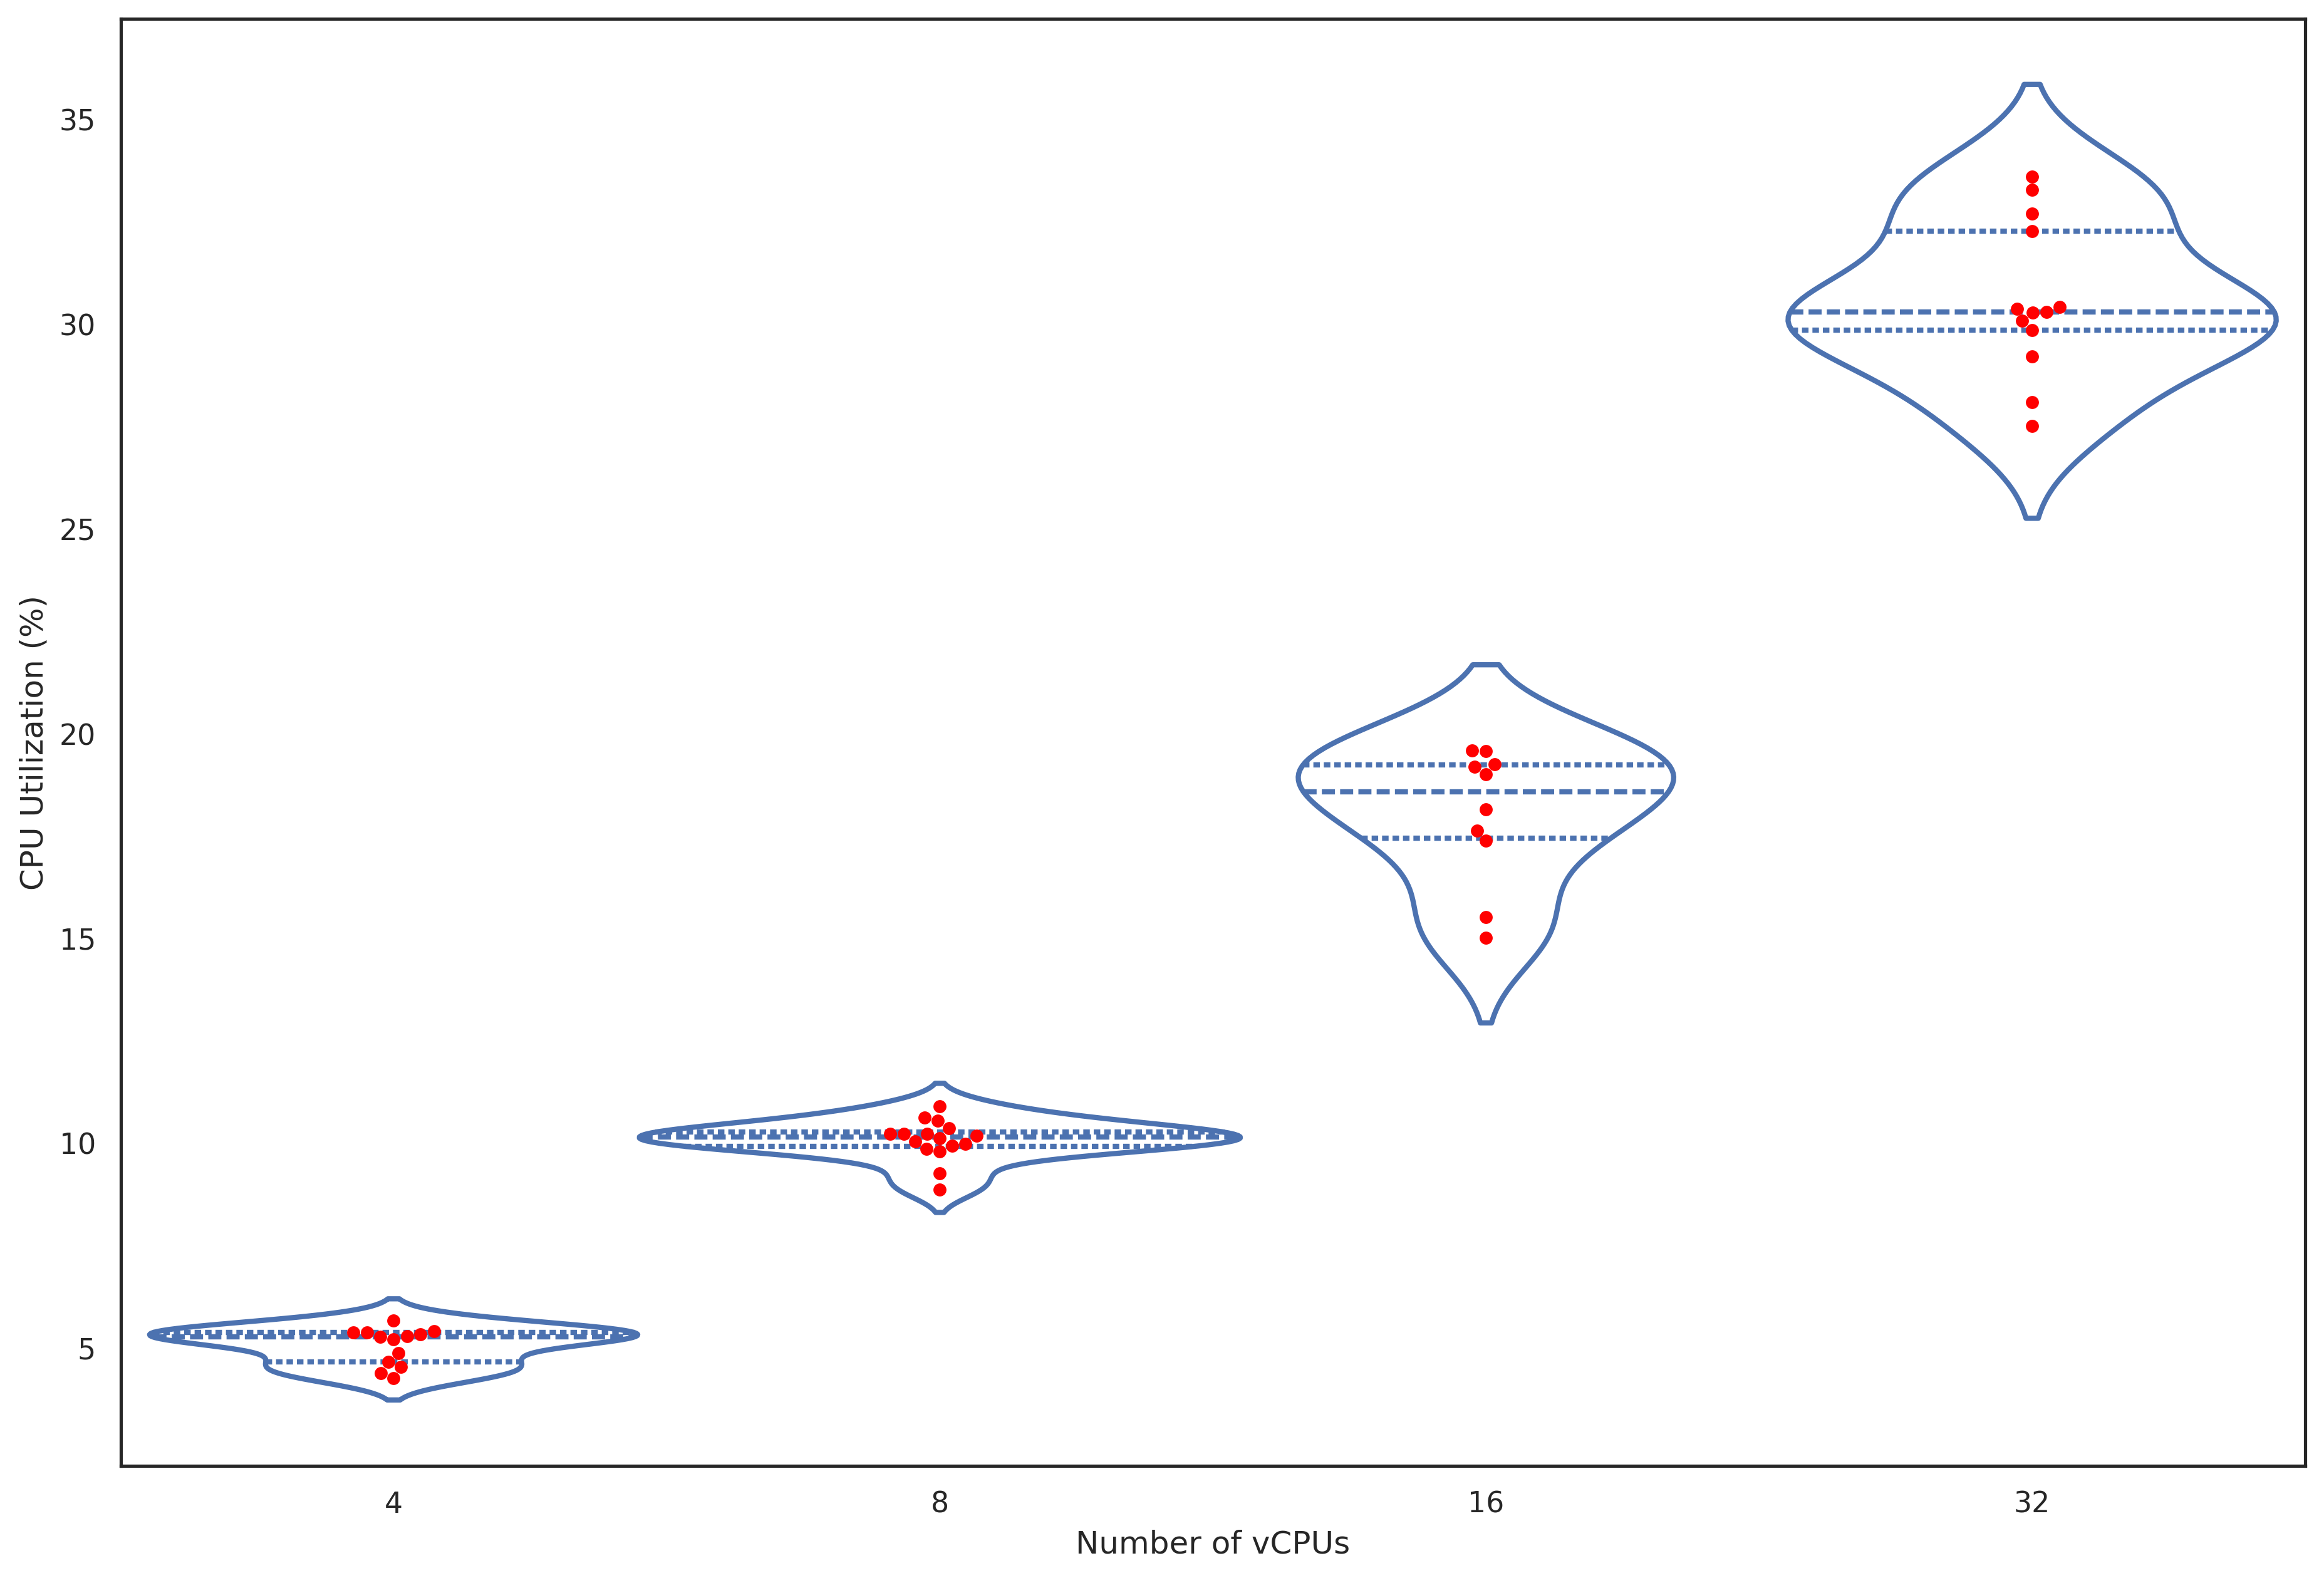

In [6]:
da.show_boxplot(
    dpp_cpu, "CPU Utilization of DPP Workflow at Varying Parallelism Degrees", metric=metric,
    x_label="Number of vCPUs", y_label="CPU Utilization (%)", store=True
)

### Normality Test: Shapiro-Wilk and QQ-Plots

In [7]:
normality = ps.test_normality(dpp_cpu, column=metric)
print(normality)

   NCPUS      STAT    PVALUE
0      4  0.885339  0.084265
1      8  0.931563  0.258066
2     16  0.855335  0.067210
3     32  0.934395  0.388513


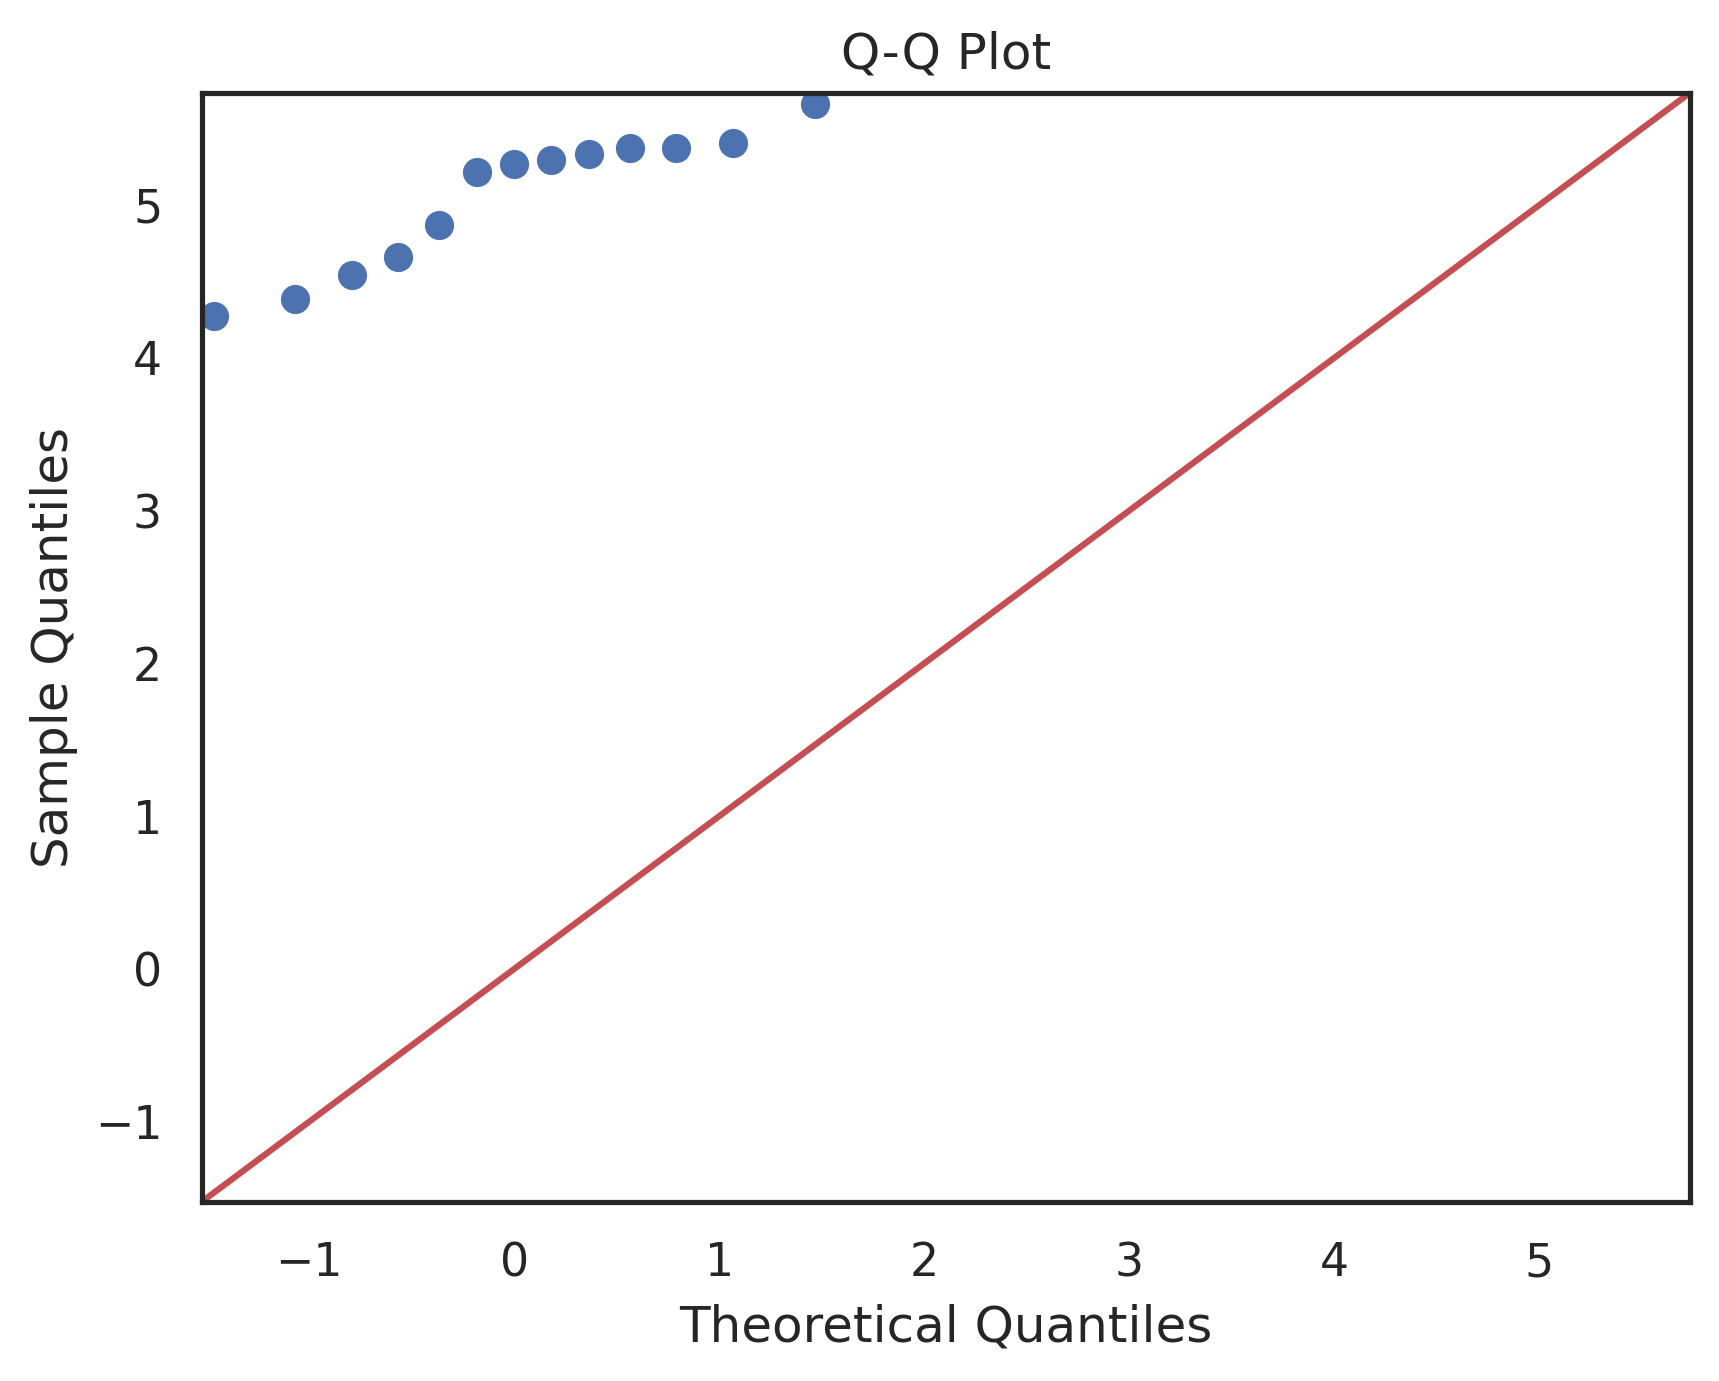

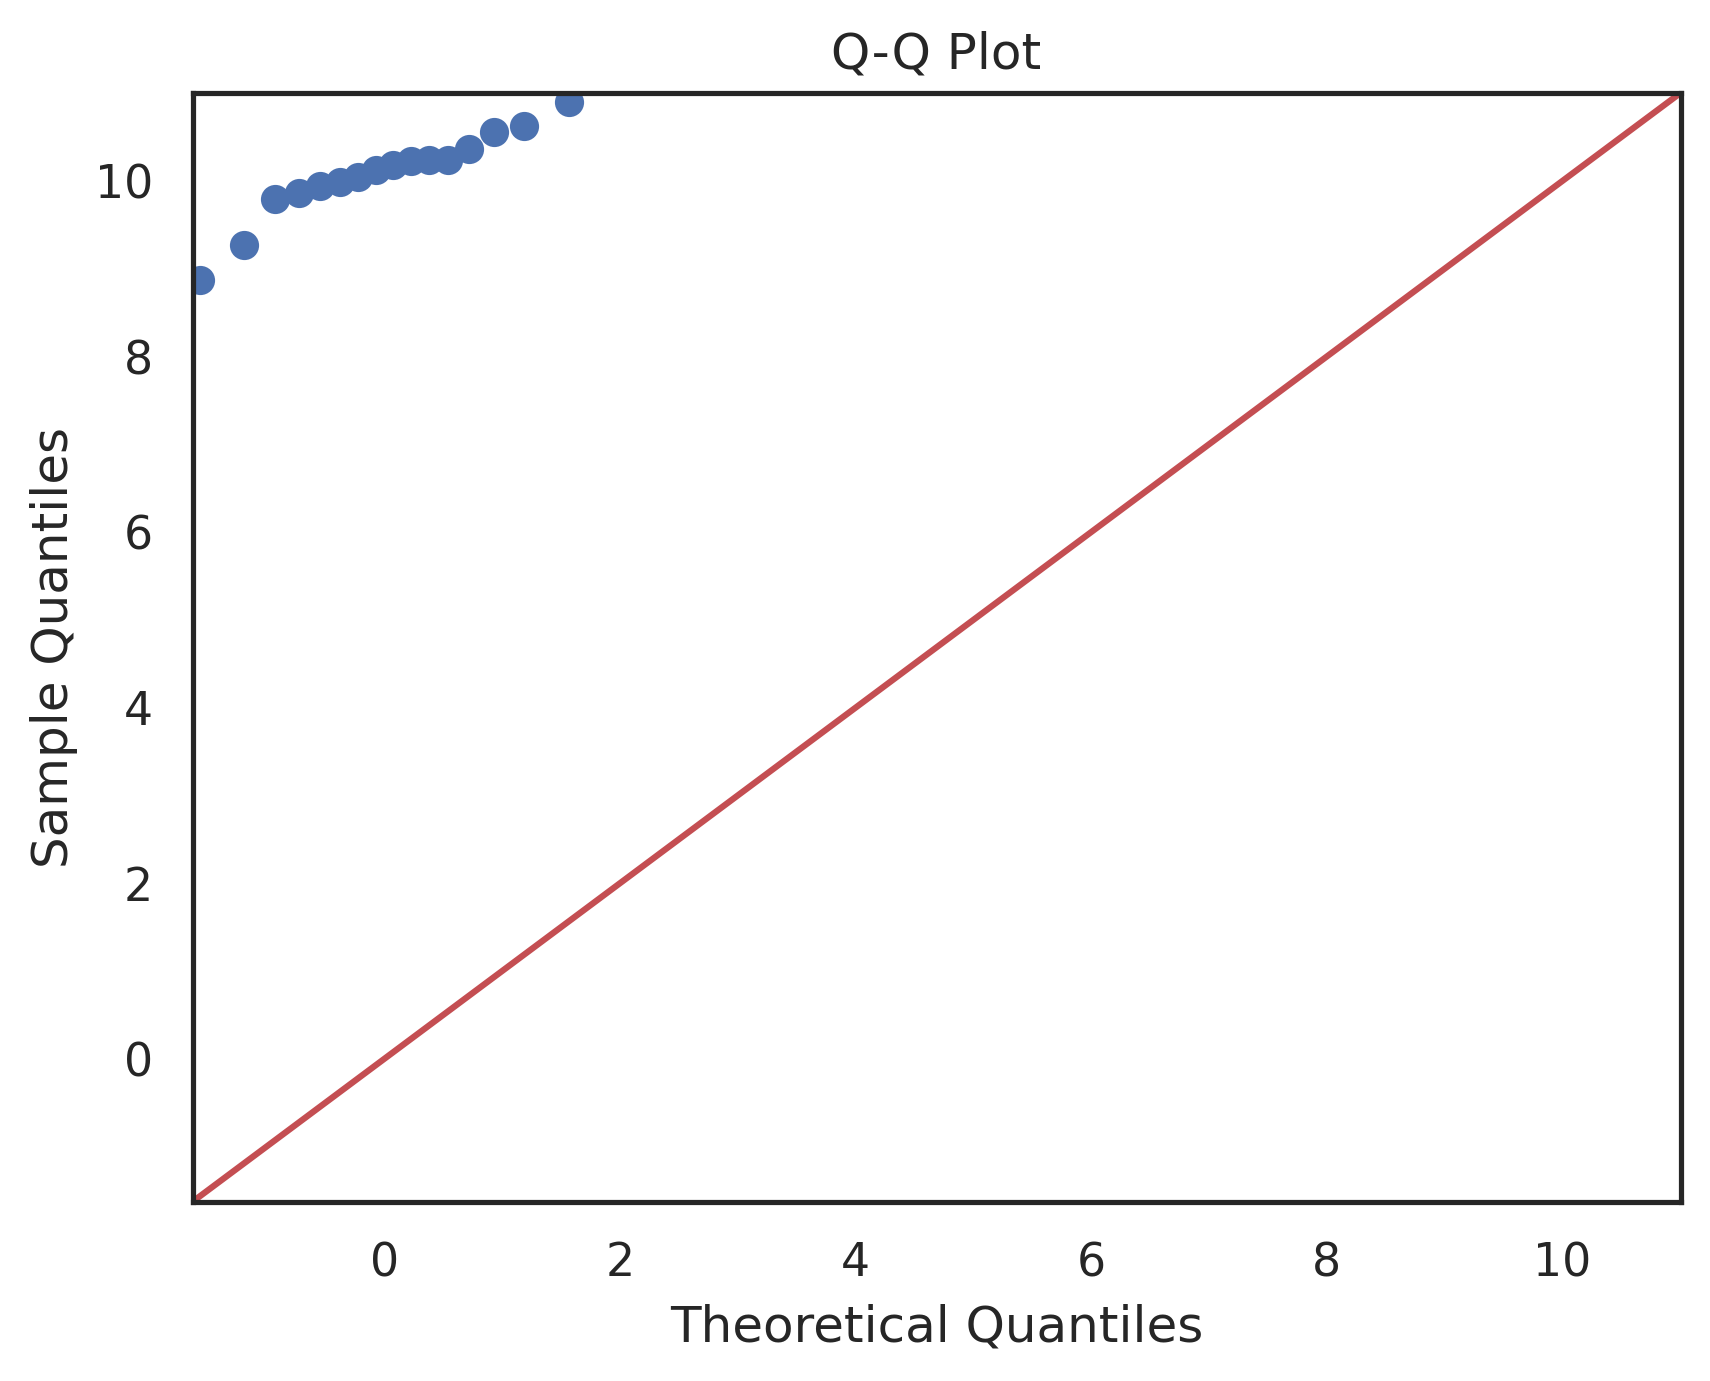

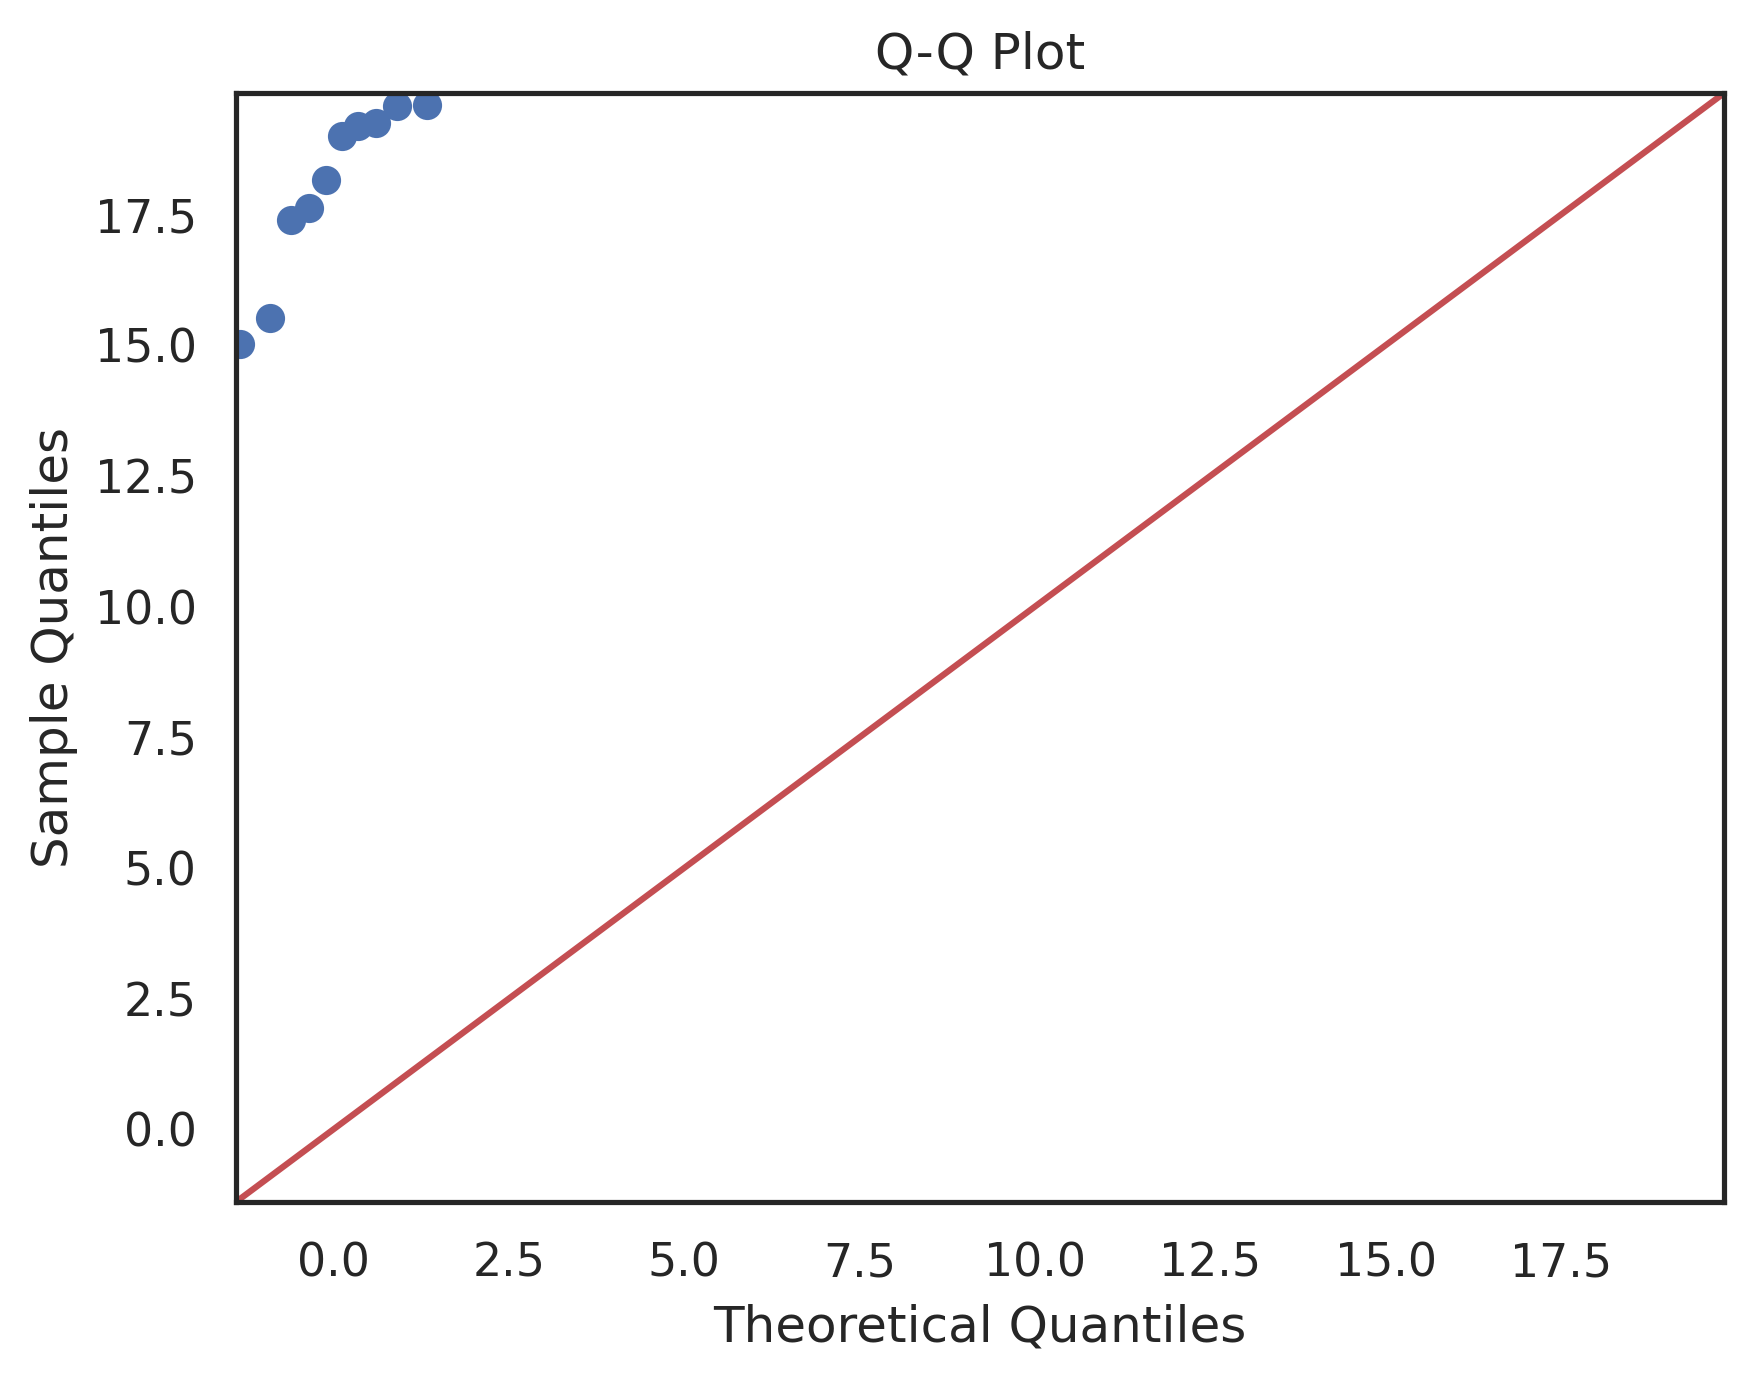

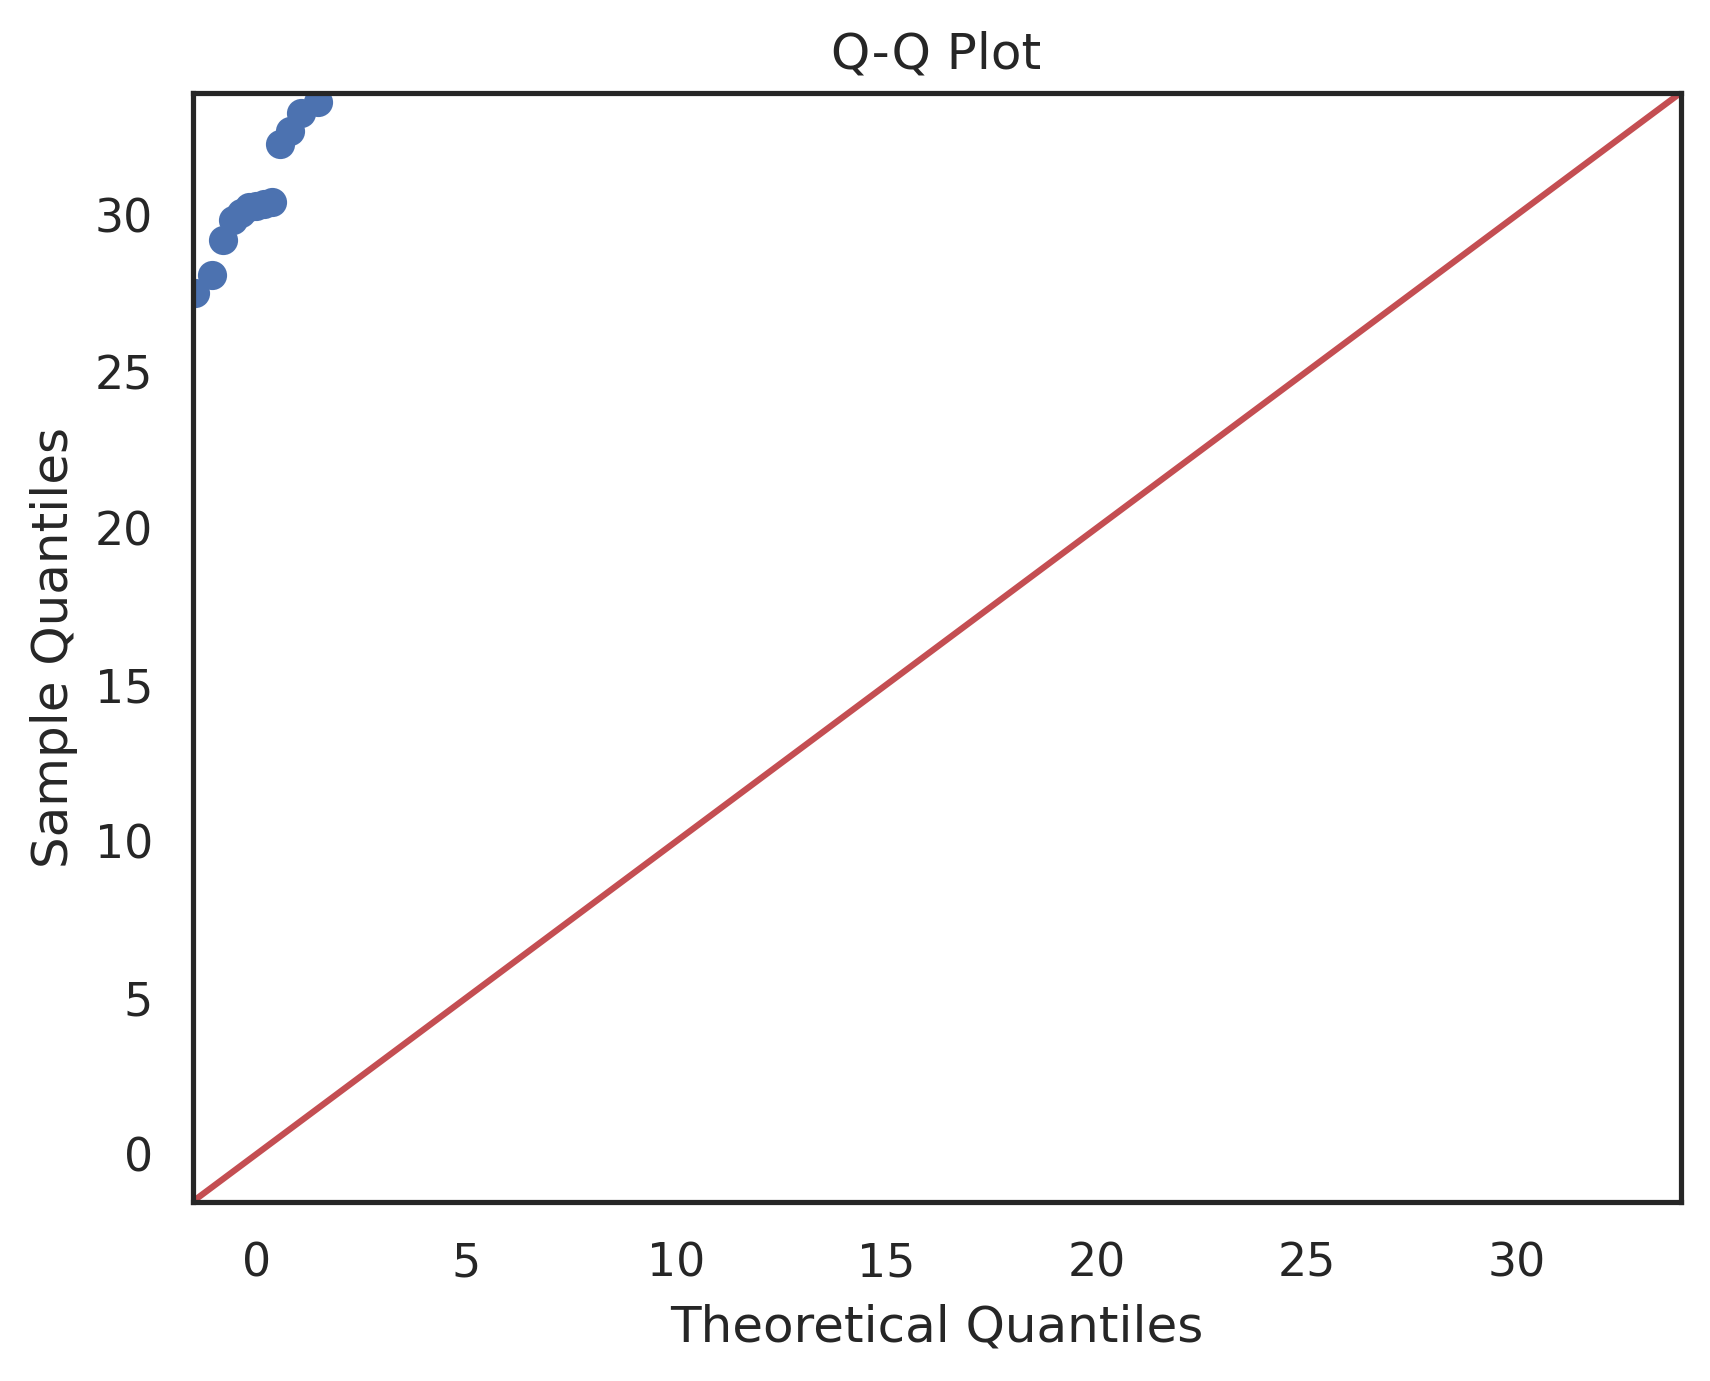

In [8]:
ps.generate_qq(dpp_cpu, column=metric)

## Hypothesis Testing: Kruskal-Wallis

In [9]:
ps.test_hypothesis_kruskal(dpp_cpu, column=metric)

(47.575471698113205, 2.621838394439671e-10)

## Effect Size: Cliff's Delta

In [10]:
ps.calc_cliffs_delta(dpp_cpu, column=metric)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",-1.0,large
1,"(8, 16)",-1.0,large
2,"(16, 32)",-1.0,large


## Effect Size: Percentage Improvement

In [11]:
ps.calc_groups_improvement(dpp_cpu, column=metric)

,CPU-GROUPS,Mean Improvement,Median Improvement,Mean Delta,Median Delta
0,"(4, 8)",-49.873086,-48.102800,-5.025925,-4.883618
1,"(8, 16)",-44.123973,-45.363757,-7.957906,-8.429456
2,"(16, 32)",-41.089969,-38.670498,-12.579714,-11.716579
3,"(4, 32)",-83.499932,-82.610216,-25.563545,-25.029653


# Docking Antibody-Antigen CPU Analysis 

In [12]:
daa = pd.read_csv('./data/clean/data_daa.csv')
daa_cpu = daa[['AveCPU', 'NCPUS']]

# Descriptive Analysis

In [13]:
for x in [4, 8, 16, 32]:
    group = ps.get_group(daa_cpu, ncpus=x)
    print(group.describe())

          AveCPU  NCPUS
count  12.000000   12.0
mean    3.514272    4.0
std     0.106469    0.0
min     3.273444    4.0
25%     3.460837    4.0
50%     3.524000    4.0
75%     3.584047    4.0
max     3.648767    4.0
          AveCPU  NCPUS
count  14.000000   14.0
mean    6.889979    8.0
std     0.239242    0.0
min     6.396684    8.0
25%     6.832047    8.0
50%     6.957204    8.0
75%     7.007862    8.0
max     7.154155    8.0
          AveCPU  NCPUS
count  10.000000   10.0
mean   12.989203   16.0
std     0.284504    0.0
min    12.648495   16.0
25%    12.728634   16.0
50%    12.963839   16.0
75%    13.264078   16.0
max    13.361327   16.0
          AveCPU  NCPUS
count  11.000000   11.0
mean   25.205457   32.0
std     0.758085    0.0
min    24.331599   32.0
25%    24.590449   32.0
50%    24.995345   32.0
75%    25.809451   32.0
max    26.352207   32.0


## Boxplots

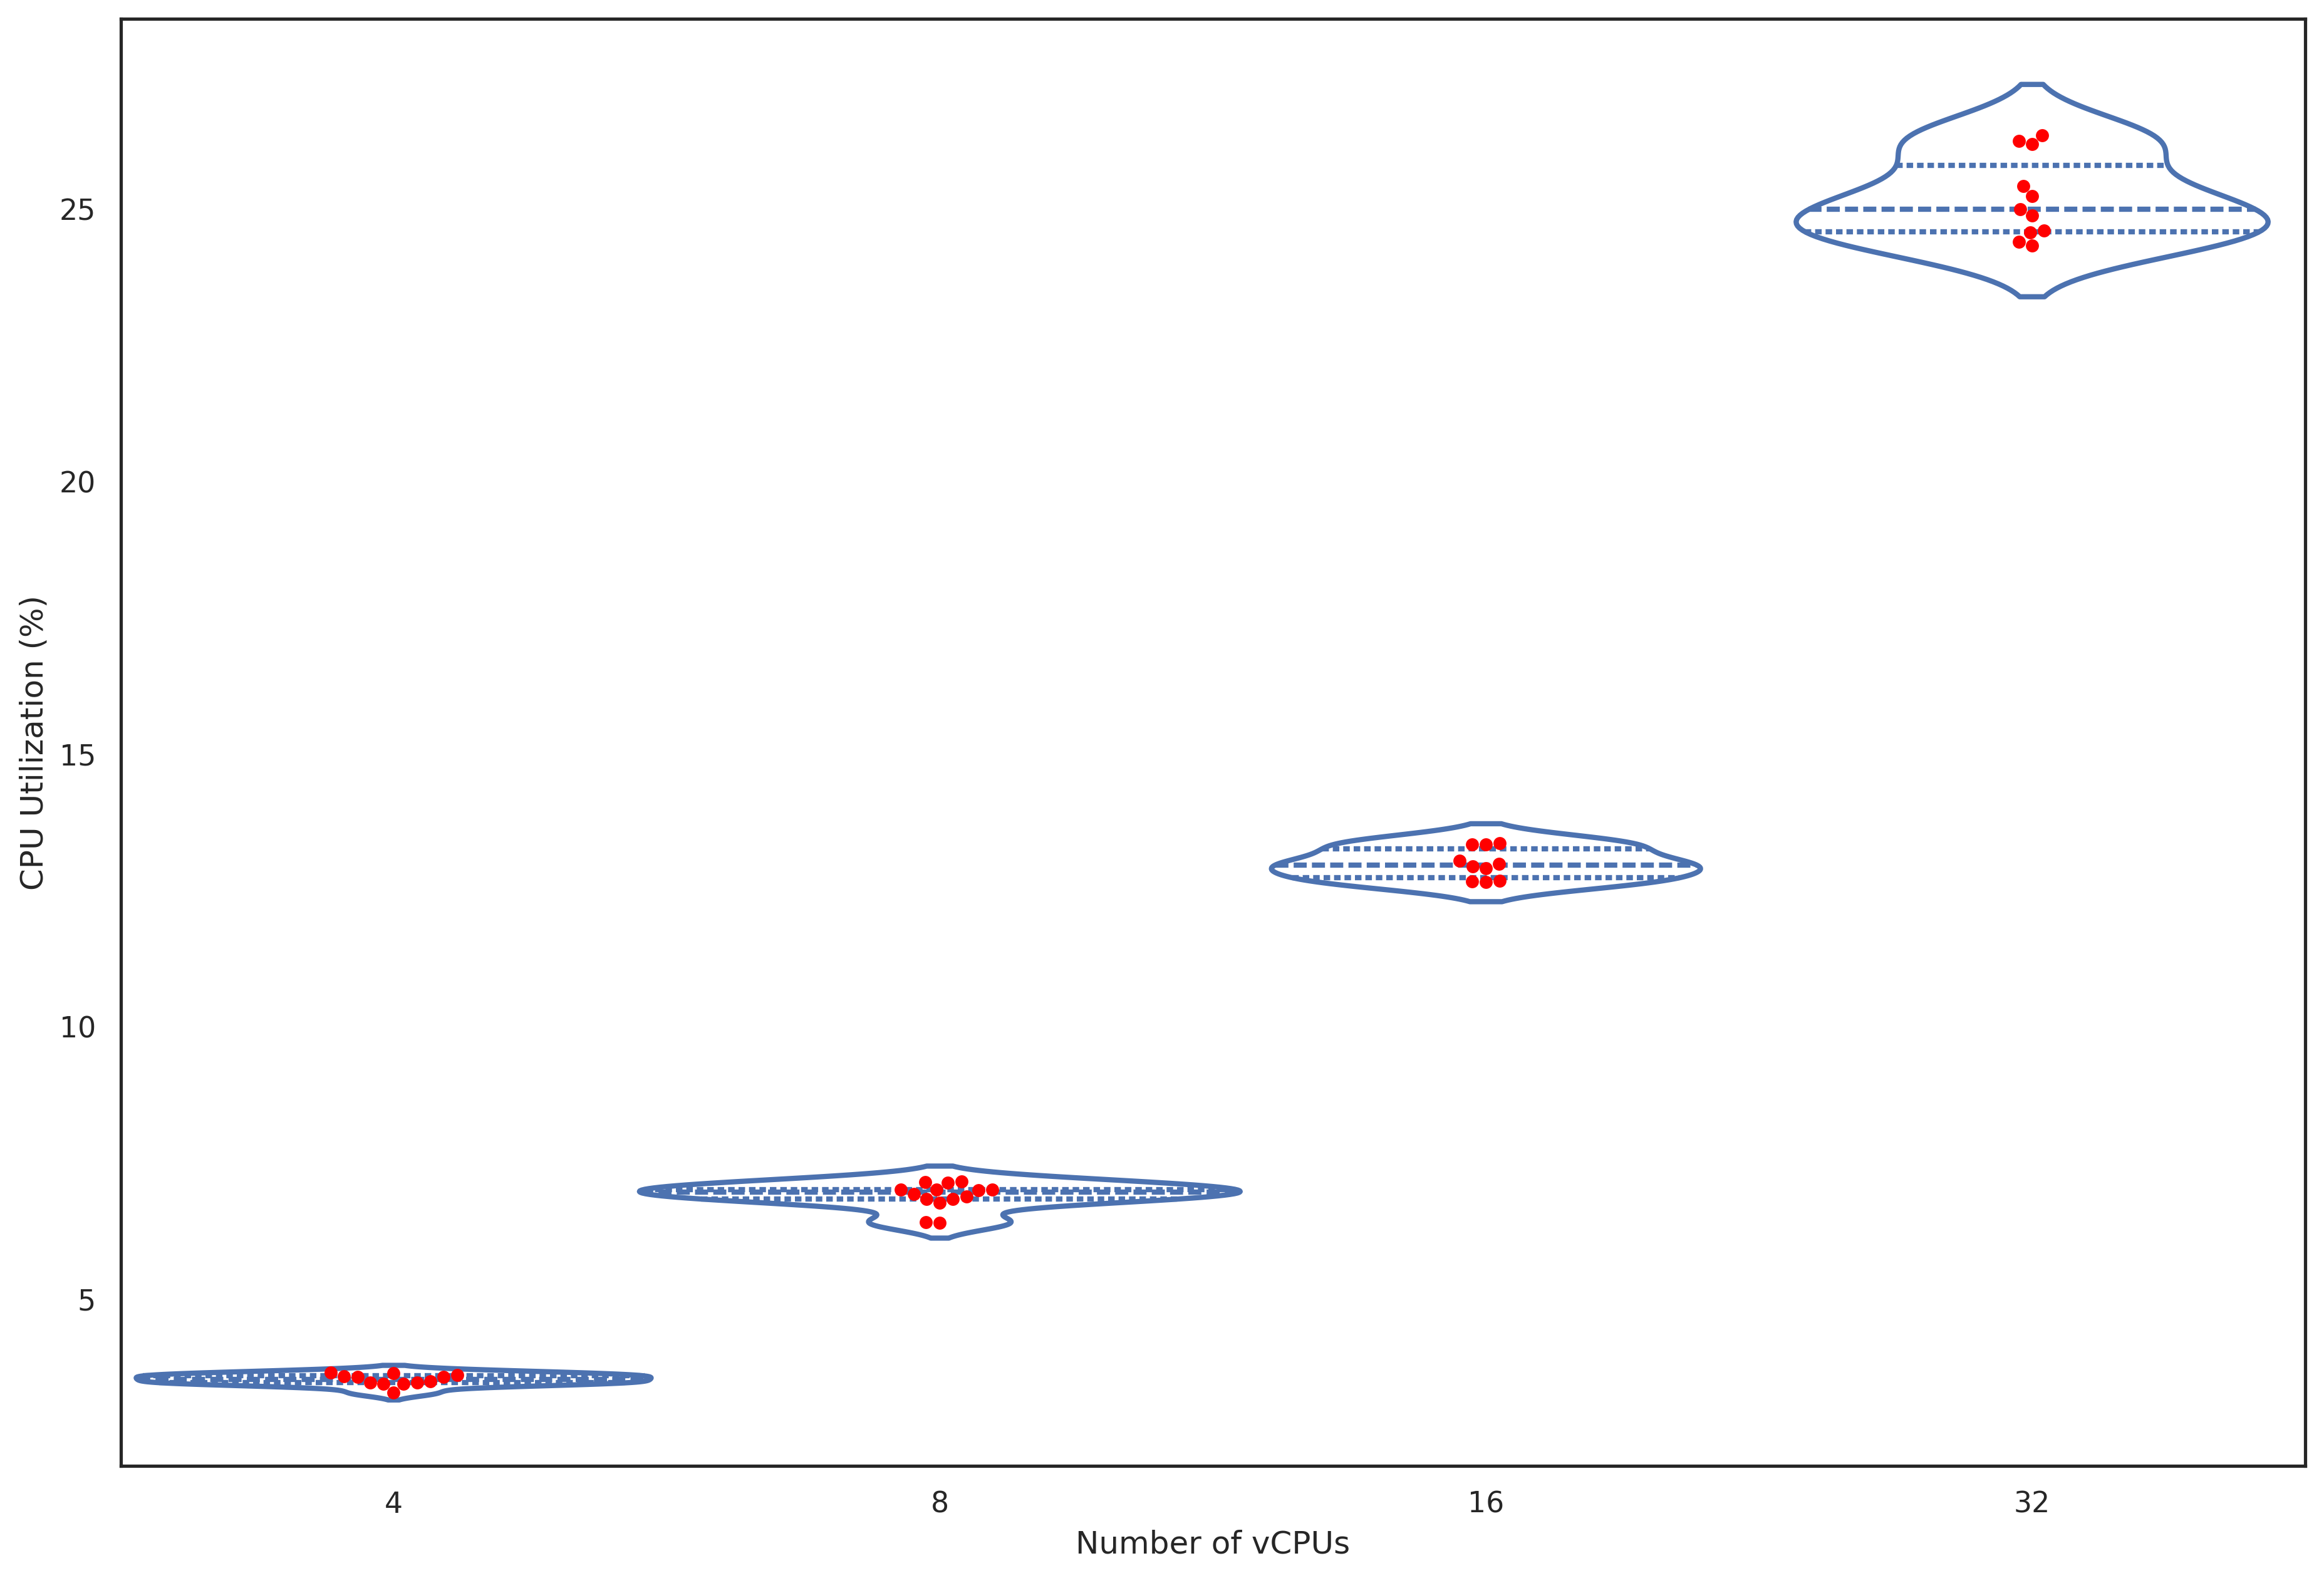

In [14]:
da.show_boxplot(
    daa_cpu, "CPU Utilization of DAA Workflow at Varying Parallelism Degrees", metric=metric,
    x_label="Number of vCPUs", y_label="CPU Utilization (%)", store=True
)

## Normality Test: Shapiro-Wilk and QQ-Plots

In [15]:
normality = ps.test_normality(daa_cpu, column=metric)
print(normality)

   NCPUS      STAT    PVALUE
0      4  0.917286  0.264224
1      8  0.850983  0.022904
2     16  0.871418  0.103839
3     32  0.883001  0.113567


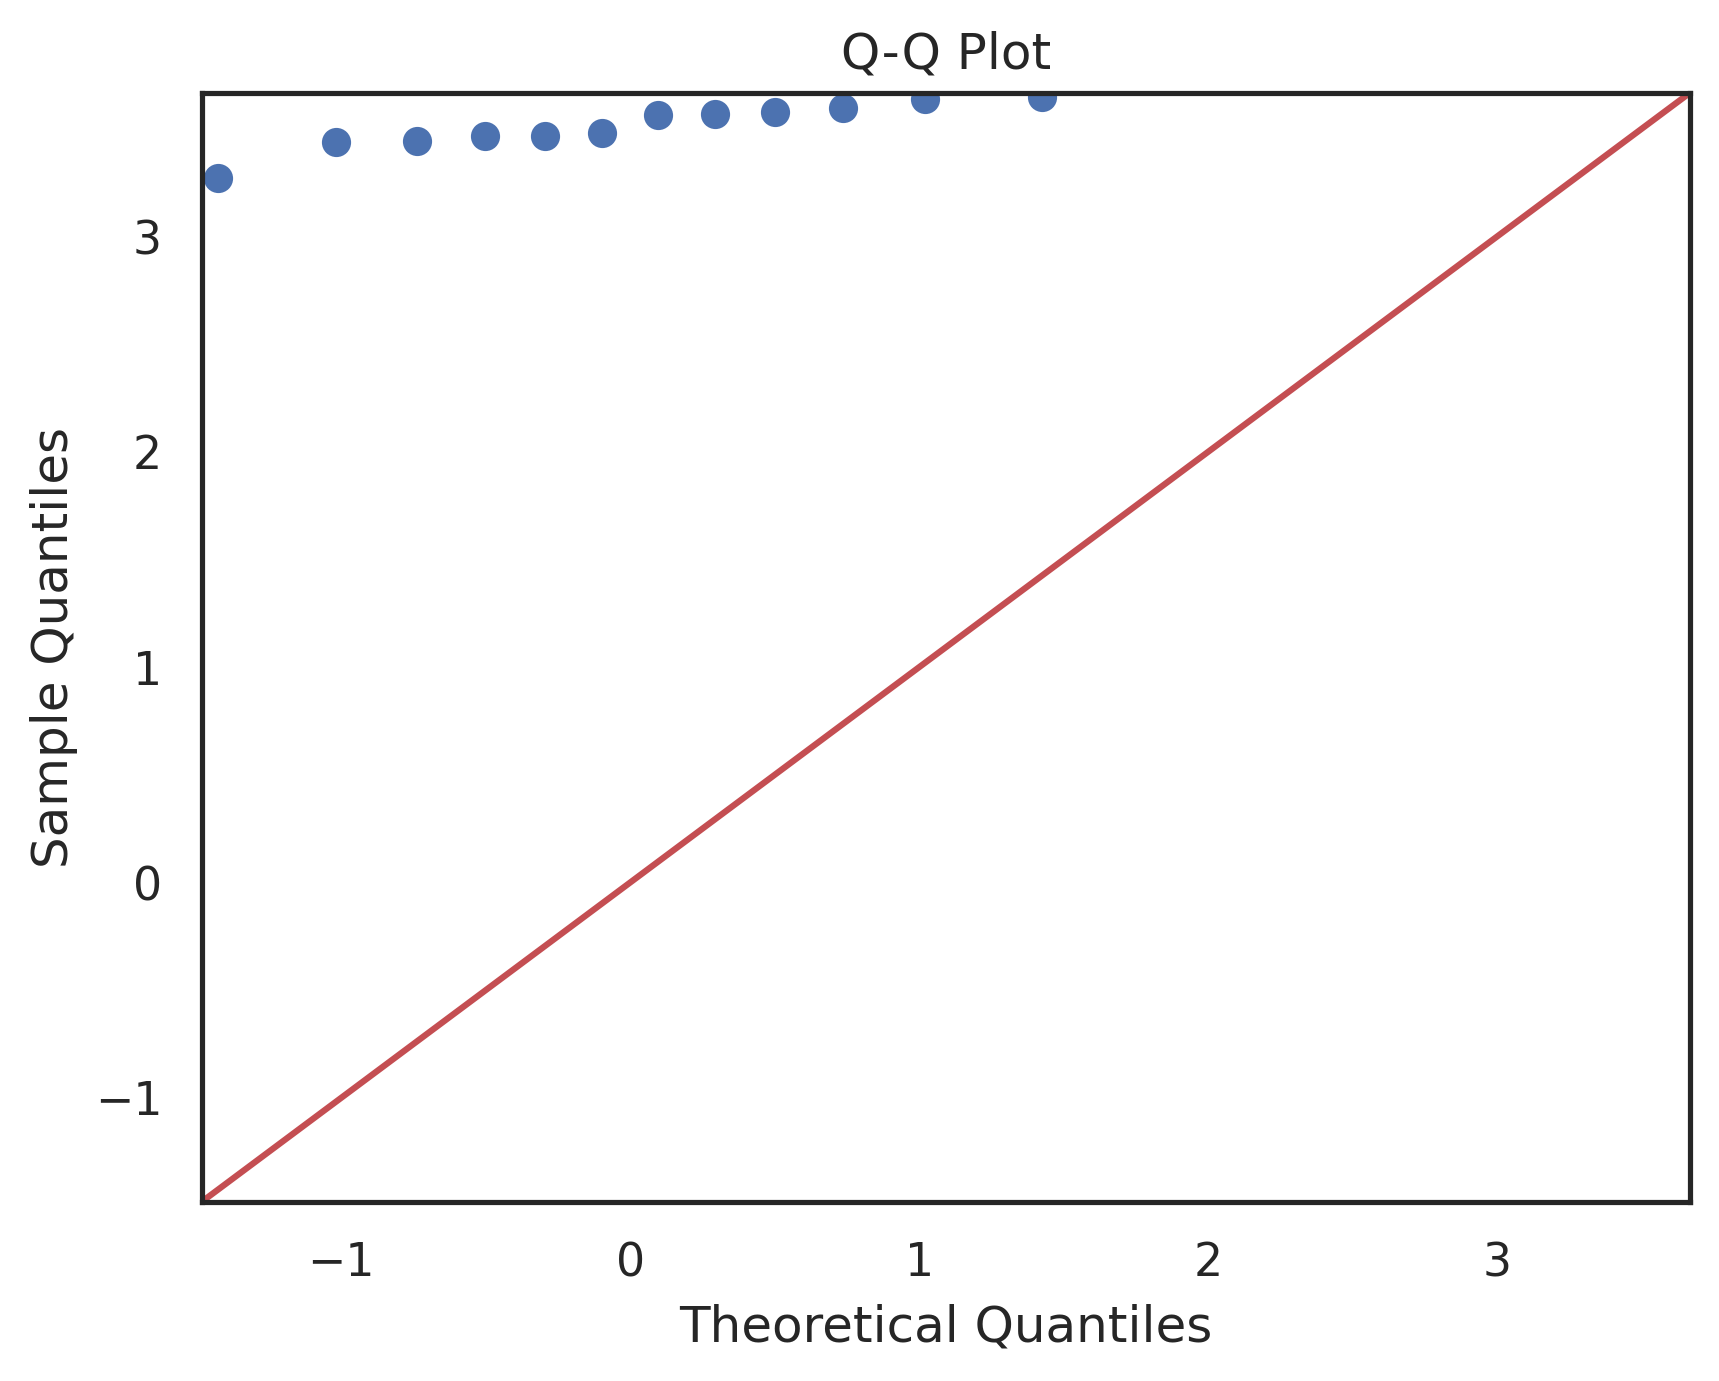

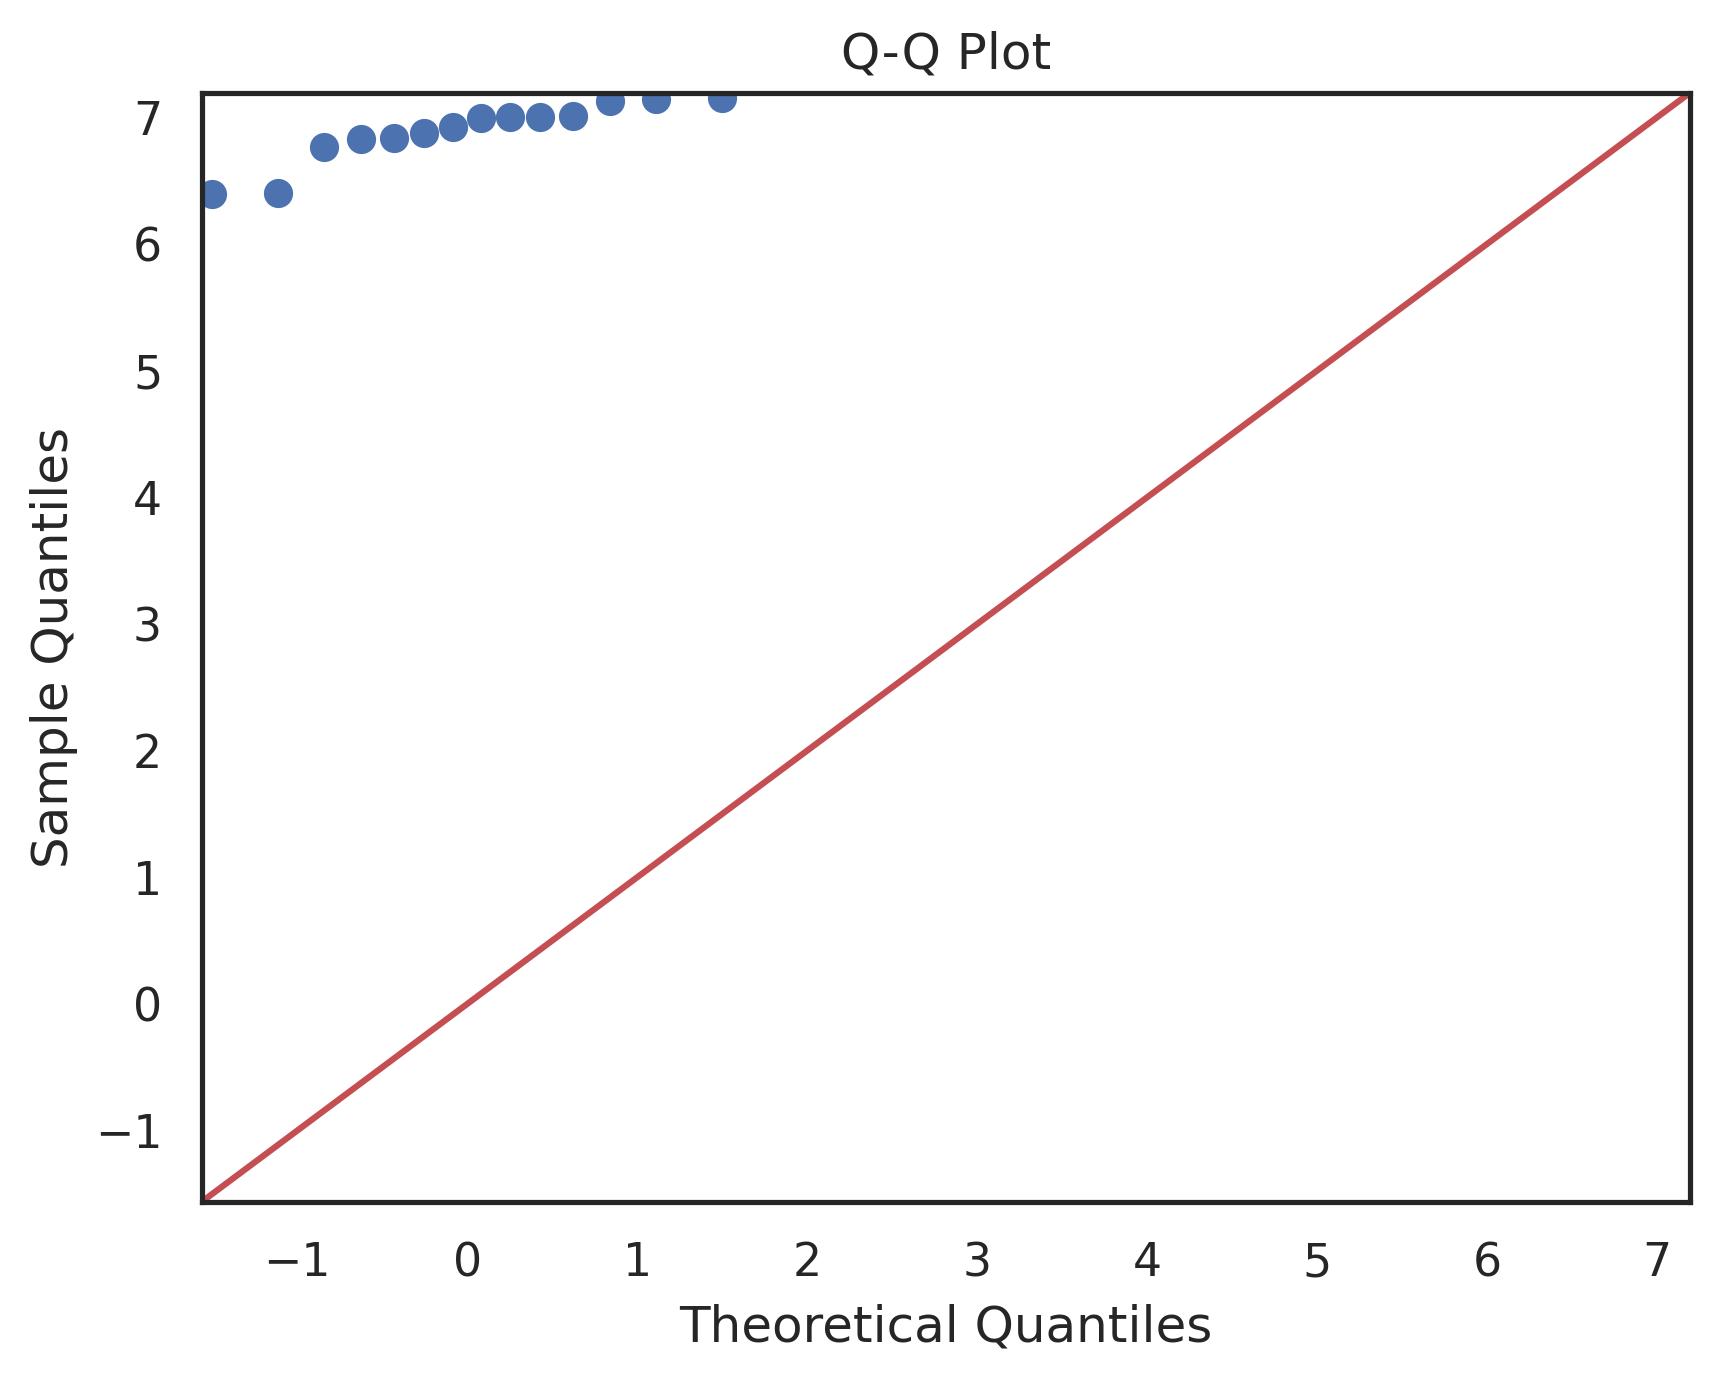

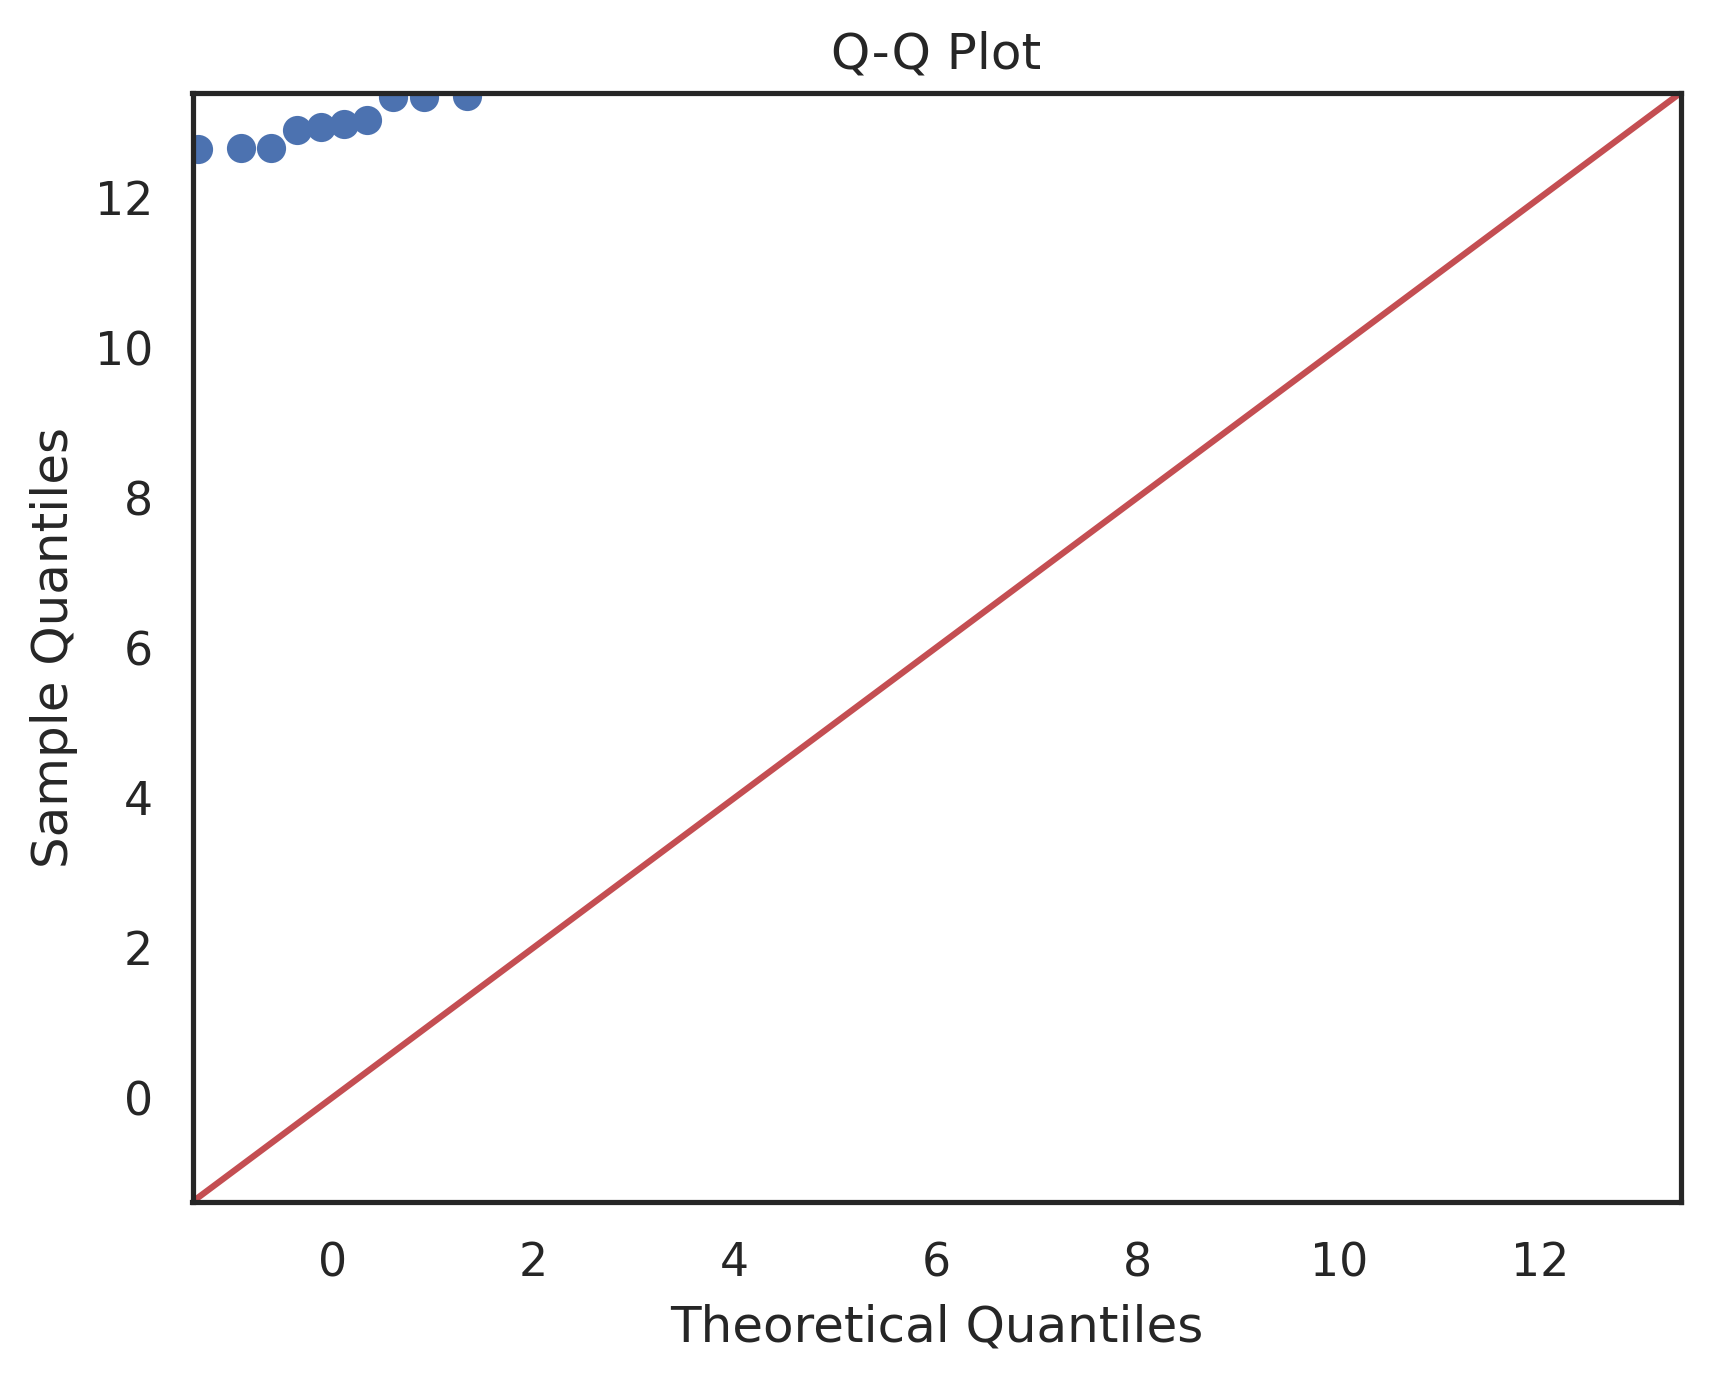

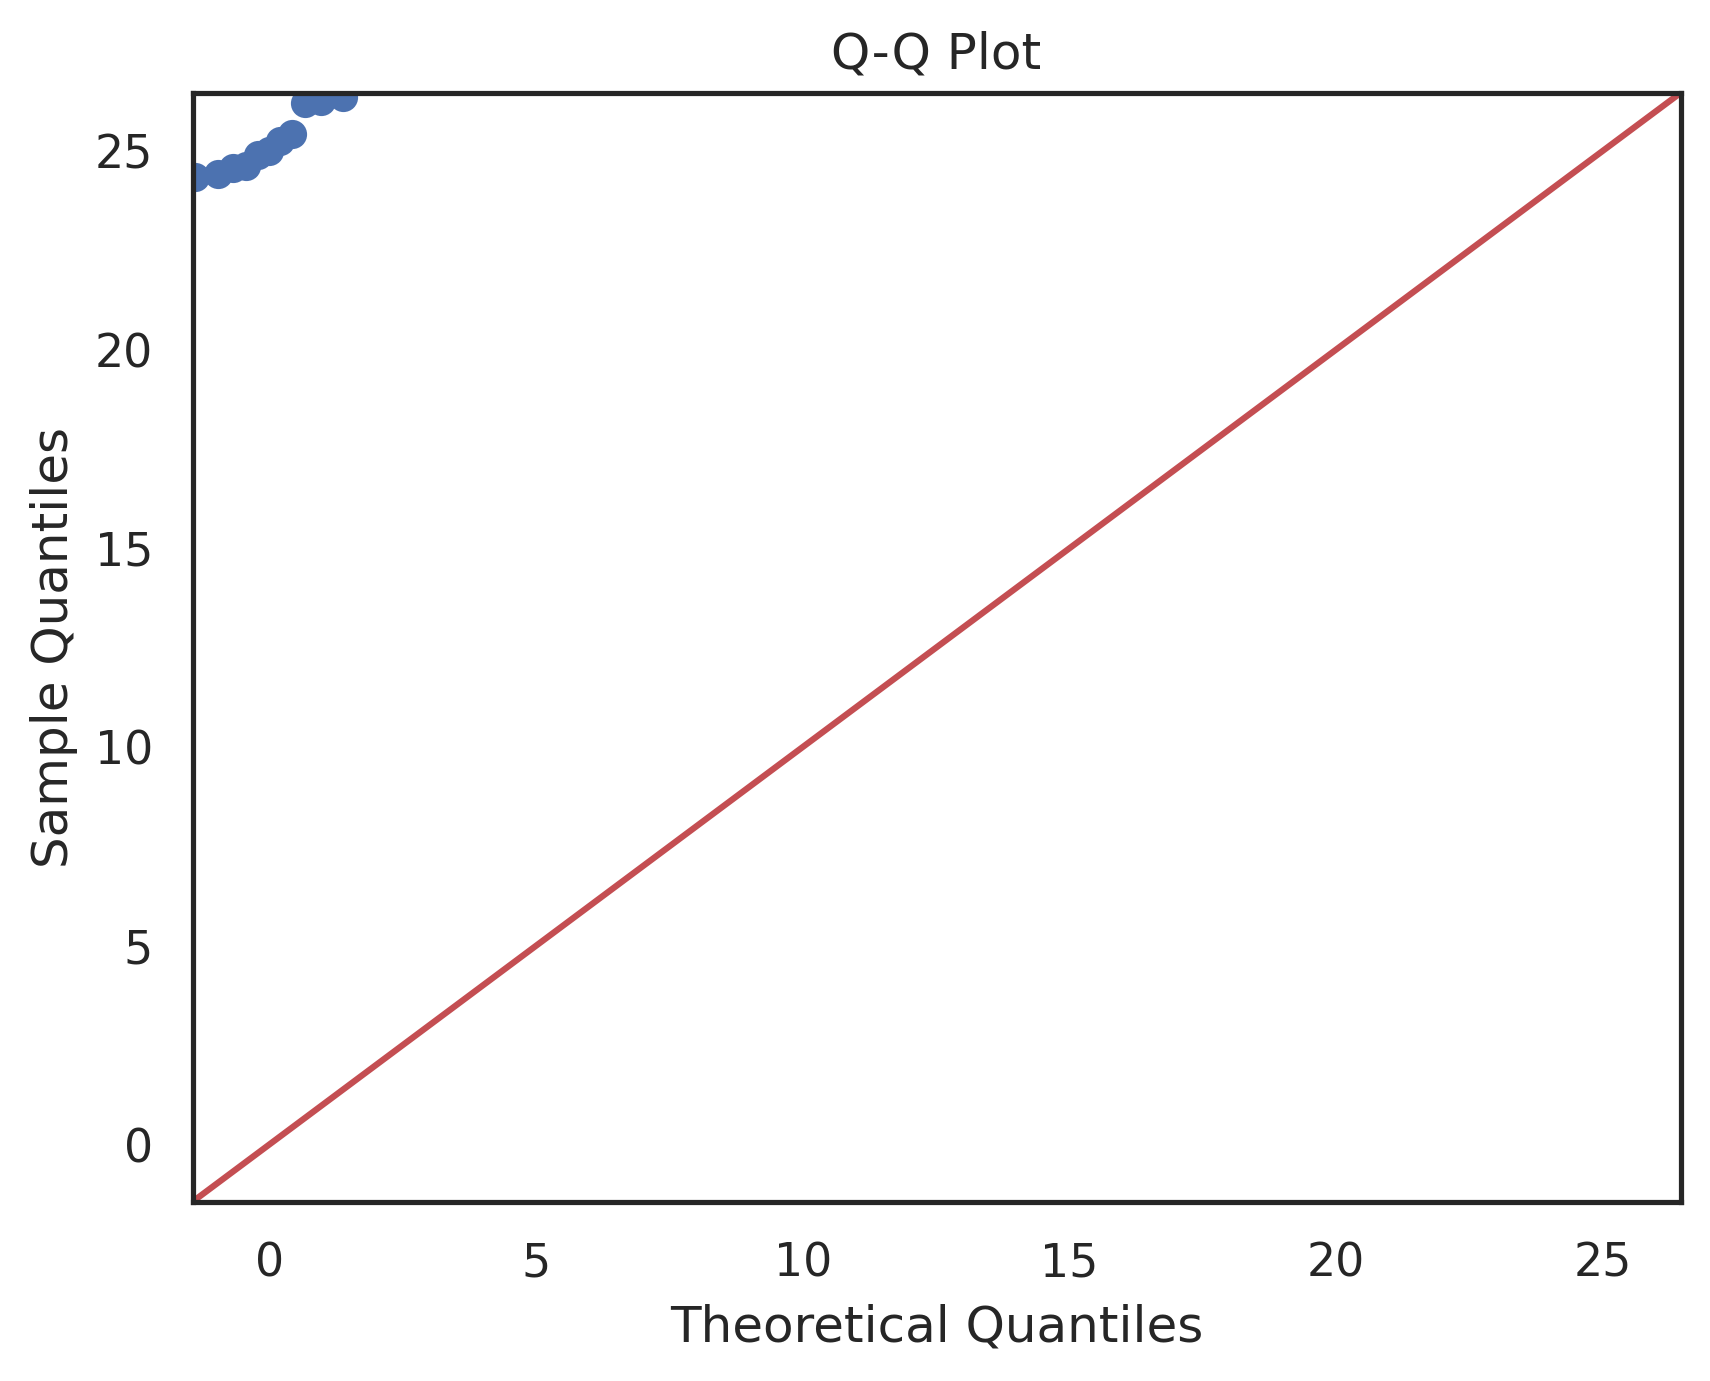

In [16]:
ps.generate_qq(daa_cpu, column=metric)

## Hypothesis Testing: Kruskal-Wallis

In [17]:
ps.test_hypothesis_kruskal(daa_cpu, column=metric)

(43.00531914893617, 2.454610623477107e-09)

## Effect Size: Cliff's Delta

In [18]:
ps.calc_cliffs_delta(daa_cpu, column=metric)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",-1.0,large
1,"(8, 16)",-1.0,large
2,"(16, 32)",-1.0,large


## Effect Size: Percentage Improvement

In [19]:
ps.calc_groups_improvement(daa_cpu, column=metric)

,CPU-GROUPS,Mean Improvement,Median Improvement,Mean Delta,Median Delta
0,"(4, 8)",-48.994444,-49.347477,-3.375707,-3.433205
1,"(8, 16)",-46.956106,-46.333764,-6.099224,-6.006634
2,"(16, 32)",-48.466702,-48.134987,-12.216254,-12.031506
3,"(4, 32)",-86.057494,-85.901376,-21.691185,-21.471345
